# Customer Segmentation — RFM + KMeans Clustering
**Dataset:** UCI Online Retail Dataset  
**Tools:** Python, Pandas, Scikit-learn, Matplotlib, Seaborn  
**Goal:** Segment customers into meaningful groups using RFM analysis and KMeans clustering

## Cell 1 — Install & Import Libraries

In [1]:
import subprocess
subprocess.run(['pip', 'install', 'scikit-learn', 'openpyxl', '-q'])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

print('✅ All libraries loaded!')

✅ All libraries loaded!


## Cell 2 — Load & Clean Data

In [2]:
# Load dataset
df = pd.read_excel('data/Online Retail.xlsx', engine='openpyxl')
print(f'Raw data: {df.shape[0]:,} rows')

# Clean data
df.dropna(subset=['CustomerID'], inplace=True)
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['CustomerID'] = df['CustomerID'].astype(int)
df['Revenue'] = df['Quantity'] * df['UnitPrice']

print(f'Clean data: {df.shape[0]:,} rows')
print(f'Unique customers: {df["CustomerID"].nunique():,}')
df.head()

Raw data: 541,909 rows
Clean data: 397,884 rows
Unique customers: 4,338


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## Cell 3 — Build RFM Table

In [3]:
# Reference date = 1 day after last transaction
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f'Reference date: {reference_date.date()}')

# Calculate RFM metrics per customer
rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('Revenue',     'sum')
).reset_index()

print(f'\n✅ RFM table created for {len(rfm):,} customers')
print('\n--- RFM Summary ---')
print(rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2))
rfm.head(10)

Reference date: 2011-12-10

✅ RFM table created for 4,338 customers

--- RFM Summary ---
       Recency  Frequency   Monetary
count  4338.00    4338.00    4338.00
mean     92.54       4.27    2054.27
std     100.01       7.70    8989.23
min       1.00       1.00       3.75
25%      18.00       1.00     307.41
50%      51.00       2.00     674.48
75%     142.00       5.00    1661.74
max     374.00     209.00  280206.02


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40
5,12352,36,8,2506.04
6,12353,204,1,89.00
7,12354,232,1,1079.40
8,12355,214,1,459.40
9,12356,23,3,2811.43


## Cell 4 — RFM Score Calculation

In [4]:
# Score each metric 1-5 (5 = best)
# Recency: lower is better (bought recently = score 5)
rfm['R_Score'] = pd.qcut(rfm['Recency'],   q=5, labels=[5,4,3,2,1]).astype(int)
# Frequency: higher is better
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)
# Monetary: higher is better
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'),  q=5, labels=[1,2,3,4,5]).astype(int)

# Combined RFM score
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Total'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

print('✅ RFM scores calculated!')
print('\nScore distribution:')
print(rfm['RFM_Total'].describe().round(2))
rfm.head(10)

✅ RFM scores calculated!

Score distribution:
count    4338.00
mean        9.02
std         3.59
min         3.00
25%         6.00
50%         9.00
75%        12.00
max        15.00
Name: RFM_Total, dtype: float64


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total
0,12346,326,1,77183.60,1,1,5,115,7
1,12347,2,7,4310.00,5,5,5,555,15
2,12348,75,4,1797.24,2,4,4,244,10
3,12349,19,1,1757.55,4,1,4,414,9
4,12350,310,1,334.40,1,1,2,112,4
5,12352,36,8,2506.04,3,5,5,355,13
6,12353,204,1,89.00,1,1,1,111,3
7,12354,232,1,1079.40,1,1,4,114,6
8,12355,214,1,459.40,1,1,2,112,4
9,12356,23,3,2811.43,4,3,5,435,12


## Cell 5 — Assign Customer Segments

In [5]:
def assign_segment(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'Potential Loyalists'
    elif r >= 3 and f <= 2 and m <= 2:
        return 'New Customers'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f >= 4 and m >= 4:
        return 'Cannot Lose Them'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost'
    else:
        return 'Needs Attention'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

print('✅ Segments assigned!')
print('\n--- Segment Distribution ---')
print(rfm['Segment'].value_counts())

✅ Segments assigned!

--- Segment Distribution ---
Segment
Champions              962
Lost                   824
Needs Attention        773
Loyal Customers        758
At Risk                454
Potential Loyalists    319
New Customers          248
Name: count, dtype: int64


## Cell 6 — Visualize Customer Segments

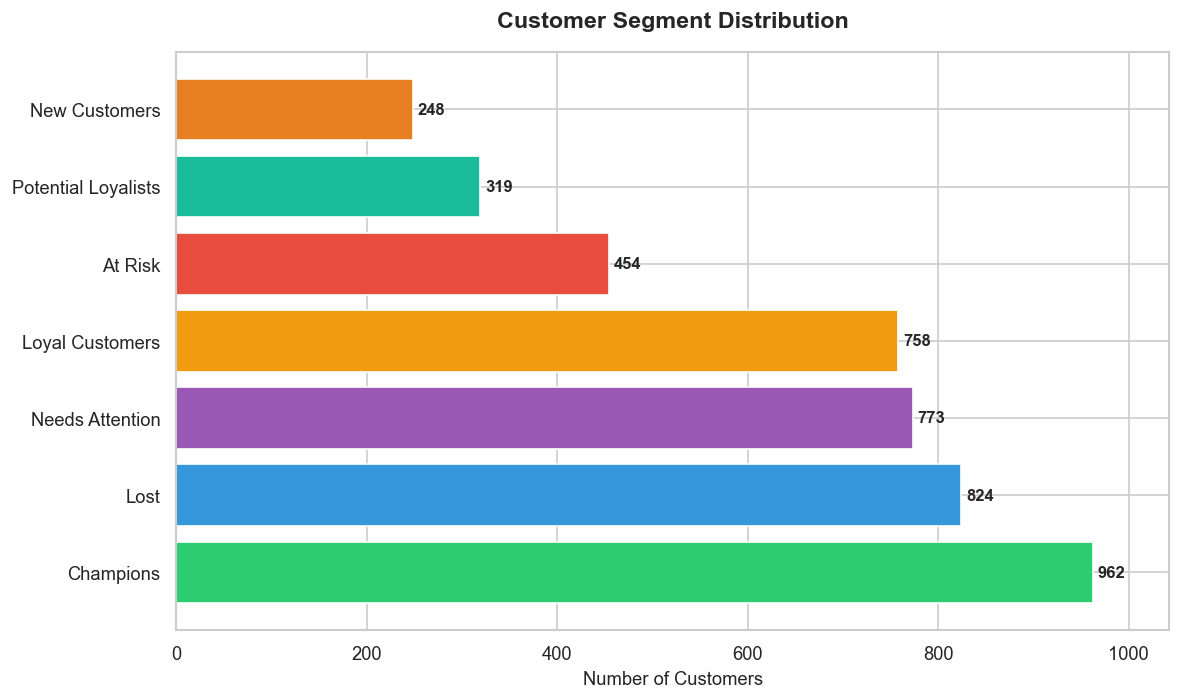

✅ Chart saved!


In [6]:
segment_counts = rfm['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Count']

colors = ['#2ECC71','#3498DB','#9B59B6','#F39C12','#E74C3C','#1ABC9C','#E67E22','#95A5A6']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(segment_counts['Segment'], segment_counts['Count'],
               color=colors[:len(segment_counts)])

for bar, val in zip(bars, segment_counts['Count']):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10, fontweight='bold')

ax.set_title('Customer Segment Distribution', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Customers', fontsize=11)
ax.set_ylabel('')
ax.set_xlim(0, segment_counts['Count'].max() + 80)
plt.tight_layout()
plt.savefig('outputs/segment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved!')

## Cell 7 — Revenue by Segment

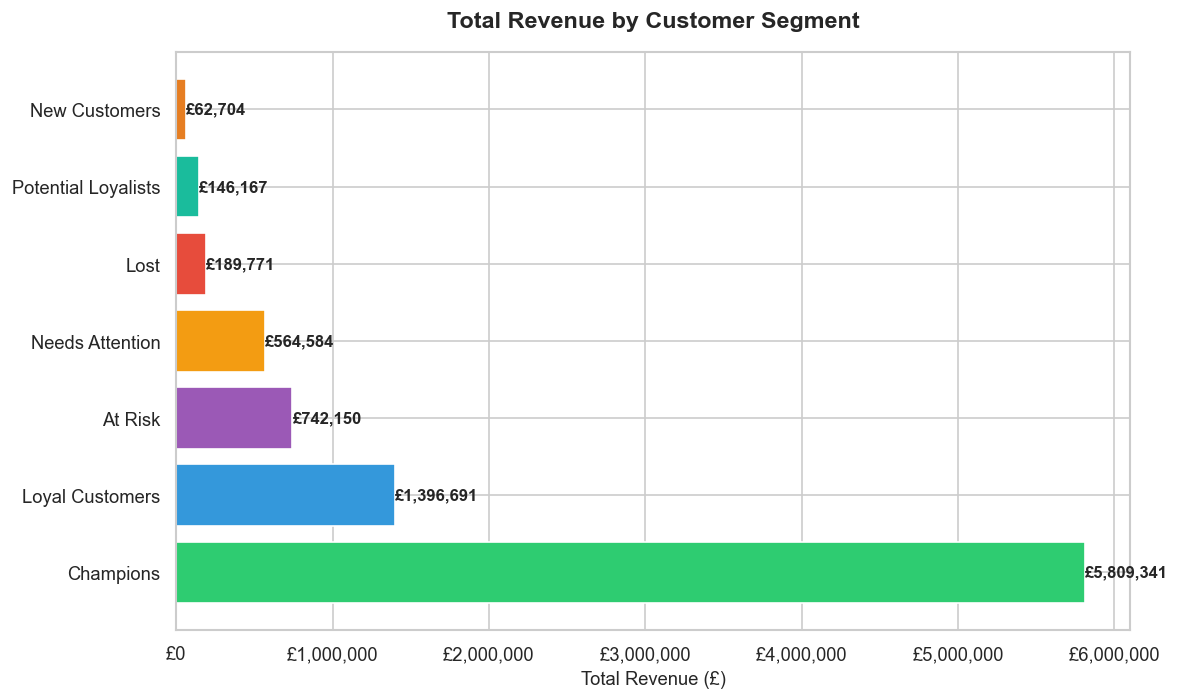

✅ Chart saved!


In [7]:
segment_revenue = (
    rfm.groupby('Segment')['Monetary']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(segment_revenue['Segment'], segment_revenue['Monetary'],
               color=colors[:len(segment_revenue)])

for bar, val in zip(bars, segment_revenue['Monetary']):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'£{val:,.0f}', va='center', fontsize=10, fontweight='bold')

ax.set_title('Total Revenue by Customer Segment', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Total Revenue (£)', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.savefig('outputs/revenue_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved!')

## Cell 8 — KMeans Clustering (Machine Learning!)

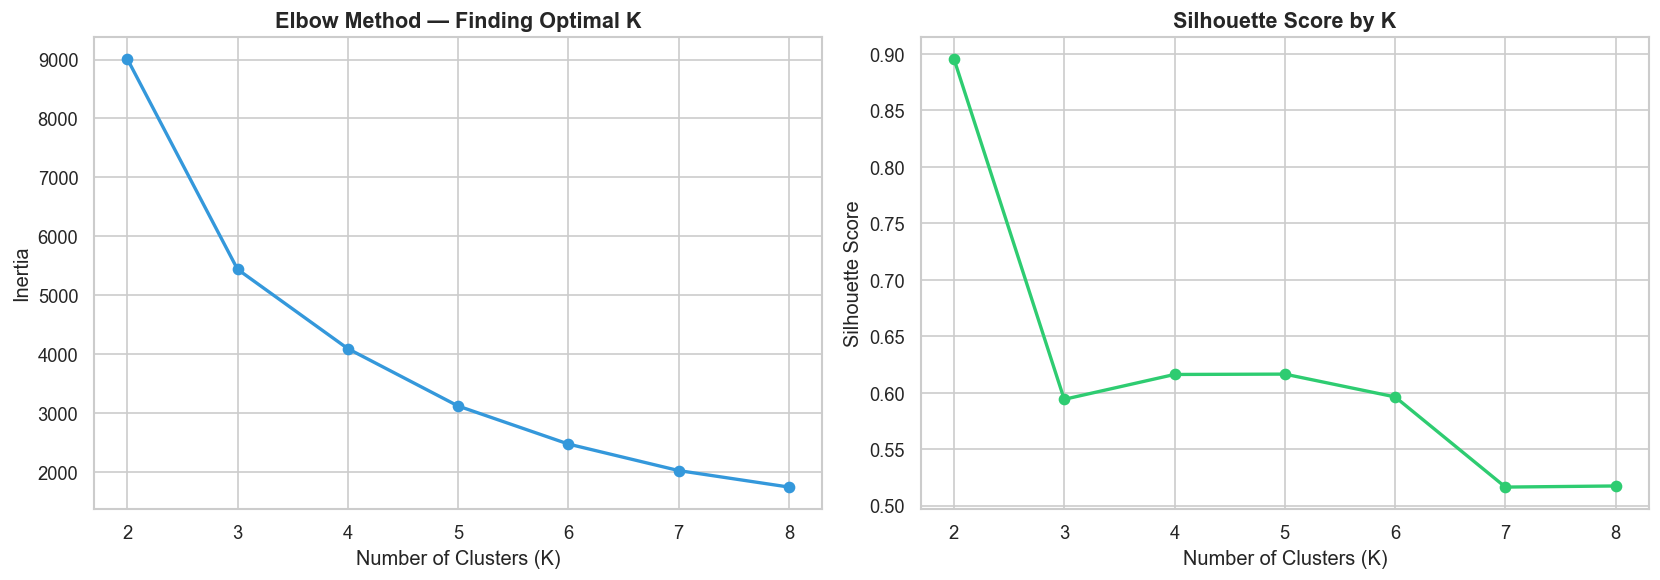

✅ Look at the elbow curve — where does the line bend? That is your best K!


In [8]:
# Prepare features for clustering
features = rfm[['Recency', 'Frequency', 'Monetary']].copy()

# Scale the features (very important for KMeans!)
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Find the best number of clusters using Elbow Method
inertias = []
silhouettes = []
k_range = range(2, 9)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(features_scaled, kmeans.labels_))

# Plot Elbow Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, marker='o', color='#3498DB', linewidth=2)
axes[0].set_title('Elbow Method — Finding Optimal K', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, silhouettes, marker='o', color='#2ECC71', linewidth=2)
axes[1].set_title('Silhouette Score by K', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.savefig('outputs/elbow_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Look at the elbow curve — where does the line bend? That is your best K!')

## Cell 9 — Apply KMeans with Best K

In [15]:
# Apply KMeans with k=4 (change this based on your elbow curve)
BEST_K = 3

kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(features_scaled)

# Summarize each cluster
cluster_summary = rfm.groupby('Cluster').agg(
    Customers = ('CustomerID', 'count'),
    Avg_Recency   = ('Recency',   'mean'),
    Avg_Frequency = ('Frequency', 'mean'),
    Avg_Monetary  = ('Monetary',  'mean')
).round(2).reset_index()

print('✅ KMeans clustering complete!')
print(f'\n--- Cluster Summary (K={BEST_K}) ---')
print(cluster_summary.to_string(index=False))

✅ KMeans clustering complete!

--- Cluster Summary (K=3) ---
 Cluster  Customers  Avg_Recency  Avg_Frequency  Avg_Monetary
       0       1082       247.11           1.58        631.42
       1       3230        41.45           4.67       1855.94
       2         26         6.04          66.42      85904.35


## Cell 10 — Label the Clusters

In [16]:
# Label clusters based on their RFM characteristics
# Look at cluster_summary output above to assign meaningful names
cluster_labels = {
    0: 'Lost / Inactive',
    1: 'Loyal Customers',
    2: 'Champions'
}
# Note: you may need to swap these labels based on your cluster_summary output
rfm['Cluster_Label'] = rfm['Cluster'].map(cluster_labels)

print('✅ Clusters labelled!')
print(rfm['Cluster_Label'].value_counts())

✅ Clusters labelled!
Cluster_Label
Loyal Customers    3230
Lost / Inactive    1082
Champions            26
Name: count, dtype: int64


## Cell 11 — Scatter Plot: Recency vs Monetary

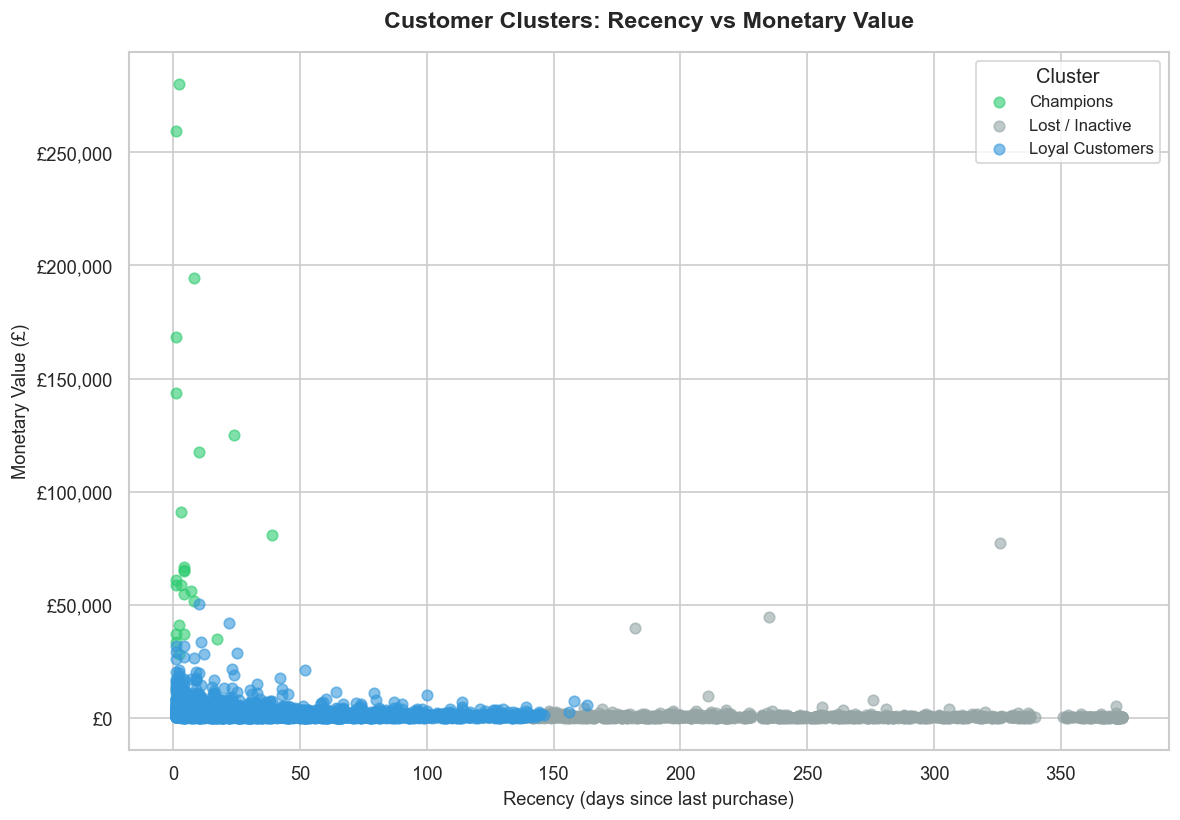

✅ Chart saved!


In [17]:
cluster_colors = {'Champions': '#2ECC71', 'Loyal Customers': '#3498DB',
                  'At Risk': '#E74C3C', 'Lost / Inactive': '#95A5A6'}

fig, ax = plt.subplots(figsize=(10, 7))

for label, group in rfm.groupby('Cluster_Label'):
    ax.scatter(group['Recency'], group['Monetary'],
               label=label, alpha=0.6, s=40,
               color=cluster_colors.get(label, '#333333'))

ax.set_title('Customer Clusters: Recency vs Monetary Value', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Recency (days since last purchase)', fontsize=11)
ax.set_ylabel('Monetary Value (£)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.legend(title='Cluster', fontsize=10)
plt.tight_layout()
plt.savefig('outputs/cluster_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved!')

## Cell 12 — RFM Heatmap by Segment

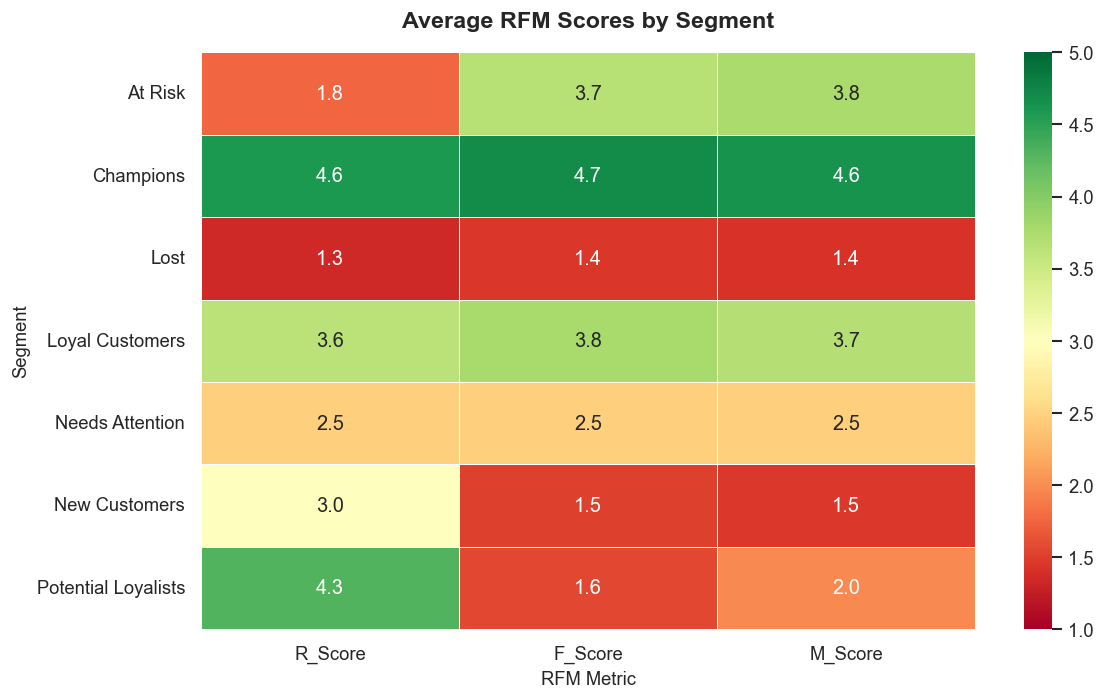

✅ Chart saved!


In [18]:
heatmap_data = rfm.groupby('Segment')[['R_Score','F_Score','M_Score']].mean().round(2)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, vmin=1, vmax=5)

ax.set_title('Average RFM Scores by Segment', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('RFM Metric', fontsize=11)
ax.set_ylabel('Segment', fontsize=11)
plt.tight_layout()
plt.savefig('outputs/rfm_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved!')

## Cell 13 — Business Recommendations

In [19]:
total_customers = len(rfm)
total_revenue   = rfm['Monetary'].sum()

print('=' * 55)
print('       💡  BUSINESS RECOMMENDATIONS')
print('=' * 55)

for segment in rfm['Segment'].unique():
    seg_data = rfm[rfm['Segment'] == segment]
    pct  = len(seg_data) / total_customers * 100
    rev  = seg_data['Monetary'].sum()
    rev_pct = rev / total_revenue * 100
    print(f'\n  {segment}')
    print(f'    Customers : {len(seg_data):,} ({pct:.1f}%)')
    print(f'    Revenue   : £{rev:,.0f} ({rev_pct:.1f}% of total)')

print('\n' + '=' * 55)
print('\n📌 Key Actions:')
print('  Champions       → Reward with loyalty program')
print('  Loyal Customers → Upsell premium products')
print('  At Risk         → Send win-back email campaign')
print('  Lost            → Offer heavy discount to re-engage')
print('  New Customers   → Onboard with welcome offers')

       💡  BUSINESS RECOMMENDATIONS

  Needs Attention
    Customers : 773 (17.8%)
    Revenue   : £564,584 (6.3% of total)

  Champions
    Customers : 962 (22.2%)
    Revenue   : £5,809,341 (65.2% of total)

  At Risk
    Customers : 454 (10.5%)
    Revenue   : £742,150 (8.3% of total)

  Potential Loyalists
    Customers : 319 (7.4%)
    Revenue   : £146,167 (1.6% of total)

  Lost
    Customers : 824 (19.0%)
    Revenue   : £189,771 (2.1% of total)

  Loyal Customers
    Customers : 758 (17.5%)
    Revenue   : £1,396,691 (15.7% of total)

  New Customers
    Customers : 248 (5.7%)
    Revenue   : £62,704 (0.7% of total)


📌 Key Actions:
  Champions       → Reward with loyalty program
  Loyal Customers → Upsell premium products
  At Risk         → Send win-back email campaign
  Lost            → Offer heavy discount to re-engage
  New Customers   → Onboard with welcome offers


## Cell 14 — Export for Power BI

In [20]:
rfm.to_csv('data/customer_segments.csv', index=False)
print('✅ Exported: data/customer_segments.csv')
print(f'   Rows    : {len(rfm):,}')
print(f'   Columns : {rfm.shape[1]}')
print('\n🎉 All done! Import customer_segments.csv into Power BI.')
print('\nColumns available for Power BI:')
print(list(rfm.columns))

✅ Exported: data/customer_segments.csv
   Rows    : 4,338
   Columns : 12

🎉 All done! Import customer_segments.csv into Power BI.

Columns available for Power BI:
['CustomerID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'RFM_Total', 'Segment', 'Cluster', 'Cluster_Label']
